# Modeling: MultiModal AI — Homework 3
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore Vision-Language Models (VLMs) and gain hands-on experience fine-tuning one.

---

## Environment Setup

Go to the top menu:  
Runtime → Change runtime type → Hardware accelerator → Choose "A100"

If you do not have Colab Pro, you can sign up for a free student Colab Pro account here:  
https://colab.research.google.com/signup


# Part 1: Reading & Reflection (20 points)

### Required Reading
[Multimodal Few-Shot Learning with Frozen Language Models](https://arxiv.org/pdf/2106.13884)

[Quality Not Quantity: On the Interaction between Datase Design and Robustness of CLIP
](https://arxiv.org/pdf/2208.05516.pdf)

[Generative AI: Here to stay, but for good?](https://www.sciencedirect.com/science/article/pii/S0160791X2300177X)

---

### Questions
1. What types of multimodal data noise are typically present in multimodal datasets, and how can they negatively impact the performance of a model during training? Can you provide examples of multimodal data points that might be considered noisy? Furthermore, how might we develop estimators capable of distinguishing between noisy and noise-free multimodal data pairs? If you have unlimited fundings to use for data filtering and data cleaning, what would be the ideal way to clean the multimodal dataset?

**There are several types of noise, such as semantic mismatch, (e.g. the image does not show what the caption describes), bias (e.g. images of doctors are always labelled as a man), duplicates, or traditionally noisy images/text (blur, typos, etc). In the worst case, such as semantic mismatch, these might push the model towards misunderstanding the world, causing generally worse robustness. As explained in the paper, there are conflicting supervision signals. In cases of bias, this might be malicious. As the model trains, the assumption is made that all samples are correct, in that the model's best possible performance on a validation set would be 100%, but if there is noise, a 100% might actually mean our model will perform worse on external tasks. An example of a multimodal data point from my dataset would be a chest x-ray where there is clearly a pacemaker present in the patients' chest, but no description or report of it in the findings, as this should always be mentioned. A very simple way to develop estimators would be to use a pretrained CLIP model, which already generates a similarity score between modalities, and use this score as the test of whether the modality pair is noise. With unlimited funds, a good way to do data filtering would be do use multiple CLIP models, trained on different datasets, and perform some ensembling over the similarity scores, before filtering out low-similarity options. While high in compute, the different models should have different distributions, and therefore ensembling adds robustness to the noise detection. In the ideal ideal world, it would be good to have experts in the domain (e.g. physicians for medical multimodal datasets, etc) manually review each modality pairing, but this is unrealistic in the scale of modern generative AI.**

2. What is the intuition of utilizing frozen large language models as the backbone for multimodal tasks? Which types of encoders would facilitate the integration of diverse information into a format understandable by LLMs? How do these LLMs process and interpret information from different modalities?

**The intuition is that the pretrained LLMs hold significantly expertise in many domains already, such as encyclopedic knowledge, fast concept understanding via few-shot learning, and adaptive responses, and thus we can utilize this expertise in a multimodal setting to create generalizable multimodal models. The encoder brings the image into an embedding space that the LLM can understand, and therefore the LLM can do its "reasoning" over those embeddings in such a way that the other modality is considered while generating text output. In the paper, they use a ResNet backbone, and then manipulate the outputs into "token" embeddings. The best encoder for this task is one that can tokenize the image, as this is the native vocabulary inside the LLM. Some options for this for image are ViT, SWiN, or VQ-VAE models, which are trained to develop these tokens for images. For any modality in general, we could do something like CLIP, since CLIP should be able to create embeddings of images that align closely to text, and therefore the LLM would be more easily compatible. Because LLMs do not process and interpret other modalities directly, we need to represent the modalities in token embeddings, so that the LLMs can utilize their underlying strong attention patterns to glean information from those embeddings.**

3. Ensuring the effectiveness of multimodal foundation models through high-quality instruction tuning is vital. A study detailed at [here](https://arxiv.org/pdf/2402.04333.pdf) introduces a strategy for selecting significant data specifically suited for enhancing instruction tuning for language models. A primary challenge in this approach is determining which data are most crucial for targeted instruction tuning. How can we accurately identify and select the most impactful data for enhancing instruction tuning in multimodal foundation models? Given the complexity of diverse and multimodal information, what strategies can ensure the effectiveness of instruction tuning data for specific tasks?

**In the given LESS paper, the main idea is that we determine data to be task-aligned when the gradients are similar to those of a small task-specific subset of preselected samples. In this way, we know that these data points encode similar patterns of those tasks. When we add multimodality, this becomes more complex, as we also have modality specific encoders to consider. Some potential ways to modify the LESS approach would be to enforce that the data chosen for instruction tuning move all modality encoders and fusion layers in the same direction as the expert subset does. We could do this by maybe extending the matching to a multi-embedding matching. For example, instead of having a single gradient embedding per datapoint, we could have multiple: one from each modality encoder, and one from the fusion section. Then, instead of matching up via some similarity between two vectors, we take the average similarity over all vectors, and keep the datapoints that have similar gradients in all parts of the model as the task-specific subset.**

4. With the advancement of generative AI, distinguishing between AI-generated and human-created content is becoming increasingly challenging. Besides watermarking, which has its limitations, are there other effective methods to differentiate between AI-generated and human-created content across various modalities (text, audio, video, image)? Or is it becoming virtually impossible to make this distinction?

**I think that in the long run, it is and will be virtually impossible to make this distinction. Currently, there are commercially available tools (e.g. ZeroGPT) that use models to check for generative AI artifacts, but the problem is that as generative AI becomes better, it should more and more closely reflect human speech patterns, and writing patterns, etc. For images and sound, and other less-understood modalities, the models are not yet good enough to escape manual checking, where you can sometimes find inaccuracies or inconsistencies in lighting, geometry, tone, etc, but as these models improve as well, it will become harder and harder. Also, each differentation model must be retrained for each new release of a SOTA model, which makes it a race when new models are being released each month.**

5. For state-of-the-art video generation models like Sora, Yann Lecun mentioned in [here](https://twitter.com/ylecun/status/1758740106955952191) that Sora does not understand the real world and its corresponding physical rules. Do you agree with this view? Can the future development of generative AI systems truly incorporate real-world knowledge, or are they limited in this aspect? Is pursuing generative AI a viable path towards achieving Artificial General Intelligence (AGI)?

**While I do in general agree with Lecun on the limitations of autoregression (and generation) as the basis of AGI, I do think that Sora "understands" the real world to some capacity. LLMs do not encode grammatical rules, but they learn them by compressing large datasets into a statistical model, and thus is able to use grammar as a by-product. Similarly, videos and the underlying physics of the world can probably be "understood" at the same level: by scale of the datasets. I think there might be specific cases, such as Lecun's example of continuing videos, where this is more complex, as he mentioned, because of the limited plausible pathways of generation, but there probably will be models that will do well to approximate these plausible pathways. However, I do think that world models are the ultimate path to AGI, as there are clear limitations of generative systems (autoregression, hallucinations, distributional shifts, etc) that are more intuitively solved with models that can compress the measured world into information-rich embeddings, then make predictions over the future based on these embeddings. In this way, I do not think that generative AI is the path to AGI, but I think it will be a good benchmark for future, more complex non-generative model systems.**


# Part 2: Testing and Fine-tuning VLMs (100 points)

# Problem 1: GPU Verification and Library Installation

Run the following code cell to verify that your environment is correctly configured.

This step ensures that **PyTorch** and **CUDA** can access the GPU.  
When the setup is correct, a **secret word** will appear in the output.

---

### In Your PDF Submission

Include:
- A **screenshot** or **code snippet** showing the printed GPU information.  
- The **secret word** displayed by your verification cell.

---

In [1]:
!pip install transformers accelerate bitsandbytes pillow torch -q

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 42
cipher_bytes = [99, 10, 102, 101, 124, 111, 10, 103, 103, 107, 99]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = torch.bitwise_xor(cipher, KEY)
    torch.cuda.synchronize()
    secret = bytes(decoded.tolist()).decode("ascii")
    print("SECRET_WORD:", secret)
else:
    print("SECRET_WORD: (not on GPU)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.4 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
GPU name: NVIDIA A100-SXM4-40GB
SECRET_WORD: I LOVE MMAI


# Problem 2: Prepare Your Dataset (20 points)

## **PLEASE READ THIS ENTIRE SECTION BEFORE PROCEDING**

For Problem 2, you will **use the dataset you have collected from Homework 1 and Homework 2 or a completely new one if you prefer** to fine-tune a Vision-Language Model (VLM).

Even if your original data isn't image-based (e.g. it's audio, time-series, or text), you should find a way to **visualize it** meaningfully. The dataset you prepare will serve as the foundation for model fine-tuning in later steps.

---

### How to Convert Your Project Data Into Images

**If your project is not originally image-based, consider these ideas to generate visual input:**

| Data Type                    | Visual Representation Example                          |
|-----------------------------|---------------------------------------------------------|
| Time-series / sensor data   | Line plots or multi-panel charts (with axis labels)     |
| Audio / Music / Physiology  | Spectrograms or waveform plots                         |
| 3d data (point clouds, CAD) | Rendering/splicing into 2D images

You are encouraged to be **creative and domain-specific** in your visualizations.

**You will need to explore ways to convert your data into images if it does not already consist of this modality. Research on your own and come up with the needed code to do so. If you are still stuck on figuring this out, please reach out to a TA for help!**

### Download Example Training Data

The next block of code will download an example dataset and create a folder named `mmai-data/`.  
Inside this folder, you will find:

```
mmai-data/
├── images/
│   ├── 1.jpg
│   └── 2.jpg
└── data.jsonl
```

The file `data.jsonl` contains your training annotations.  
Each line represents one training example with the following fields:

```json
{
  "image": "images/1.jpg",
  "question": "List objects you see.",
  "answer": "cat, sofa, blanket, remote, cushion"
}
```

---

### Your Task

Now, prepare your own dataset following the same structure as the example.


Example structure:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   ├── image_02.jpg
│   ├── ...
└── data.jsonl
```

As part of this task. You should split the data into a train and test split. **The test split should consist of the images of data that you will not use in training.**


## **Loading in the dataset**

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [80]:

# I have images in MyDrive/MIT/6.S985/images/, and a dataframe containing info at MyDrive/MIT/6.S985/... which I convert to the required data.jsonl format below
import os
import pandas as pd

print(f"There are {len(os.listdir('/content/drive/MyDrive/MIT/6.S985/images/'))} images")

df = pd.read_csv('/content/drive/MyDrive/MIT/6.S985/cleaned_cxr.csv')

basic_prompt = """Describe all abnormal clinical findings for this chest X-ray: """
df['basic_prompt'] = basic_prompt

df.head(2)

There are 1476 images


,img_id,image,findings_section,impression_section,basic_prompt
0,19991135_54742755,./drive/MyDrive/MIT/6.S985/images/19991135_547...,Heart size is borderline enlarged but unchange...,No acute cardiopulmonary abnormality. Bullous ...,Describe all abnormal clinical findings for th...
1,19991135_51777681,./drive/MyDrive/MIT/6.S985/images/19991135_517...,PA and lateral radiographs of the chest were a...,1. No significant interval change. 2. Post-sur...,Describe all abnormal clinical findings for th...


## **Train/Test Split**

In [81]:
# here, we do the train/test split
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

print(f"Total size: {len(df)}")
print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")

Total size: 1476
Train size: 1180
Test size: 296


In [82]:
# for use later, I also save this as a JSONL file as desired

train_jsonl = train[['image', 'findings_section', 'basic_prompt']]
train_jsonl = train_jsonl.rename(columns={'findings_section': 'answer', 'basic_prompt': 'question'})
train_jsonl.to_json('/content/drive/MyDrive/MIT/6.S985/data_train.jsonl', orient='records', lines=True)


test_jsonl = test[['image', 'findings_section', 'basic_prompt']]
test_jsonl = test_jsonl.rename(columns={'findings_section': 'answer', 'basic_prompt': 'question'})
test_jsonl.to_json('/content/drive/MyDrive/MIT/6.S985/data_test.jsonl', orient='records', lines=True)

## **Visualizations**

##############################
FINDINGS:  The heart size is enlarged but similar to prior exam. The mediastinal and hilar contours are within normal limits. The lung volumes are low with bibasilar atelectasis, more pronounced on the left than the right and there is no large pleural effusion or pneumothorax. There is no evidence of pulmonary edema or thickened septal lines. Multiple compression fractures of the lower thoracic spine have not changed since prior CT.


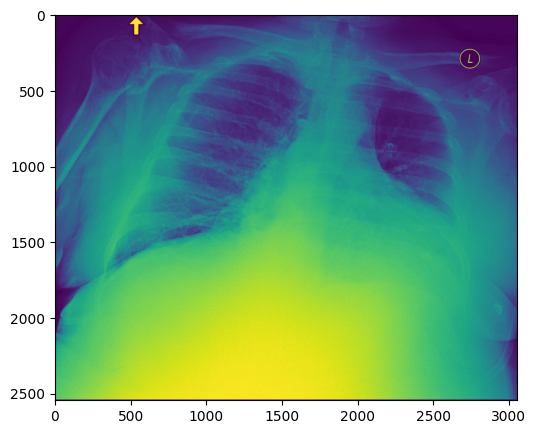




##############################
FINDINGS:  Frontal and lateral views of the chest and 2 additional views of the left-sided ribs were obtained. A BB marker projects over the lateral ninth and ___ left ribs indicating patient's site of concern. No displaced fracture is seen. The lungs are clear without focal consolidation. No pleural effusion or pneumothorax is seen. The cardiac and mediastinal silhouettes are unremarkable. There may be very minimal left basilar linear atelectasis/scarring.


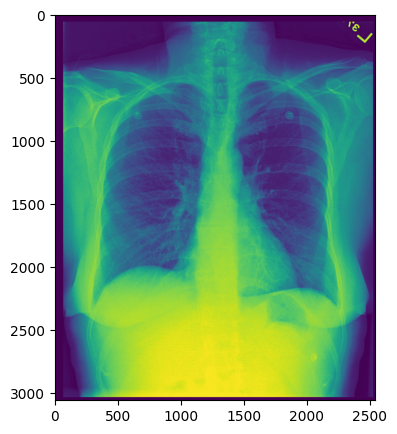

In [83]:
# visualizations of prompts and the corresponding findings
import matplotlib.pyplot as plt
from PIL import Image

for i in range(2):

    print("#" * 30)

    plt.figure(figsize=(10, 5))

    # the finding
    print("FINDINGS: ", train['findings_section'].iloc[i])

    # getting the images
    img = Image.open(train['image'].iloc[i])
    plt.imshow(img)
    plt.show()
    print("\n\n")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


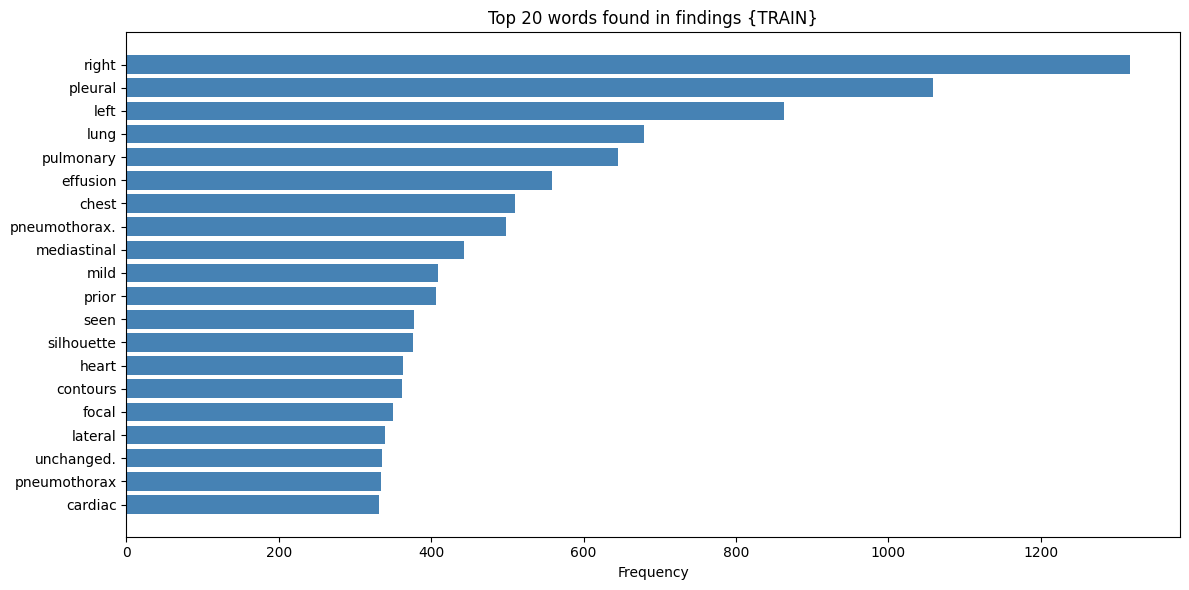

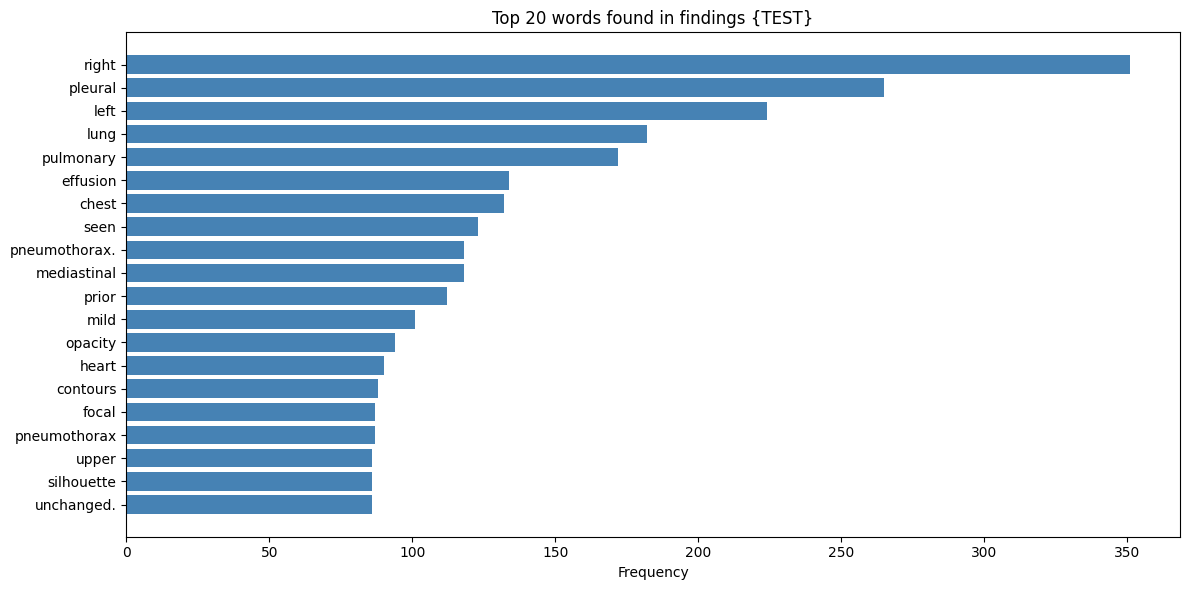

In [84]:
# we can also visualize the free text found in the findings section

from collections import Counter
import numpy as np
from nltk.corpus import stopwords # im using this to get rid of articles and prepositions
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def visualize_top_20(df, title):
  all_text = ' '.join(df['findings_section'].astype(str))
  words = [w for w in all_text.lower().split() if w not in stop_words and len(w) > 2]
  word_counts = Counter(words)
  top_20 = dict(word_counts.most_common(20))

  plt.figure(figsize=(12, 6))
  plt.barh(list(top_20.keys()), list(top_20.values()), color='steelblue')
  plt.xlabel('Frequency')
  plt.title(title)
  plt.gca().invert_yaxis()
  plt.tight_layout()
  plt.show()

visualize_top_20(train, "Top 20 words found in findings {TRAIN}")
visualize_top_20(test, "Top 20 words found in findings {TEST}")

We see very similar distributions in top 20 words, which means that the train and test set distributions in content are probably similar. This is what we expect and desire.

## Questions to Answer:

*   Explain some possible issues with converting non-image data into images (even if you did not have to do so, discuss what could be some issues).

**The main issue with converting non-image data into images is that non-image data might not have a intuitive and equally informative visual representation. For example, with text, we can do visualizations over text length distriubtions, or top-k words as I have done above, but these are always necessarily missing some information from that modality. In general, when we visualize modalities as 2D images, we either lose information when we compress them, or we might lose interpretability, like in the case of text (we lose grammar), or we might lose the temporal element, such as with time-series data.**

*   What are some possible issues with using visual representations of your data. Discuss some drawbacks of doing this (if you did not have to do the conversion as your data was already in the form of images, then discuss the drawbacks of converting those images to another modality like text, audio, etc.).

**Since I have images, I will answer the converse. If I were to represent these images as text, for example, we fall into similar pitfalls as discussed in question (1) of this section, where we are inherently reducing the total amount of information. Even though text may describe specific artifacts, it will never be able to give us the same intuitive understanding of the image that the visual representation does. More specifically, we lose information such as spatiality and granular detail. Converting to a modality such as audio would have similar effects, we would be maybe describing the image, but we would not be able to glean the same spatial detail from that description.**

* Discuss the strategy you decided on how to split your data into train/test splits. Why did you settle on this? Were any other alternative splits considered?

**To split my data into train/test, I simply used a built in function (sklearn's train_test_split). This is because in my dataset, I know that each patient is only represented once (I have preprocessed it to be this way beforehand), such that we are not leaking patient information from the train population to the test population. Other considerations for splitting datasets could be balance, but since I am using free-text and images, there are no traditional "labels" or positive/negative samples to stratify for. I also use a random state for reproducibility. Some alternative split options could be doing k-fold cross validation, but this is resource-consuming and probably unnecessary for my task.**



# Problem 3: Baseline Inference (10 points)

# Problem 3.1 Load the Model

Begin by running the following code to **load the base model** into memory. This step is required before training or making predictions.


In [59]:
import io, requests, torch
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# 1) Load model + processor (processor handles BOTH text + vision)
processor = AutoProcessor.from_pretrained(model_id)
processor.tokenizer.padding_side = "left"
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
print("Model and tokenizer loaded successfully.")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and tokenizer loaded successfully.


# Problem 3.2: Run the Model on Your 4 Held-Out Images

In this step, you will use the **pre-trained** `Qwen2.5-VL-3B-Instruct` model (no fine-tuning yet) to answer questions about the **held-out images** that were **not used in training**. You will then compare the model’s predictions with the ground-truth labels and reflect on its performance.

---

## Instructions

1. **Select four held-out images**  
   Choose four test images from your dataset that were excluded from training and prompt development.

2. **Ask a consistent question**  
   Use the same question for all images, or a small set of label-aligned questions.

3. **Run the model**  
   Use the provided code cell to run inference with the pre-trained model.  

4. **Record your results**  
   For each image, collect the model’s raw output and compare it to the ground-truth label(s). If there are too many images, then show a few examples.

---

## Suggested Output Format

| Image ID/URL | Question | Model Output | Ground Truth | Result |
|---------------|-----------|---------------|---------------|---------|
| `img_001.jpg` | “What objects are visible?” | cat, sofa | cat, sofa | Correct |
| `img_002.jpg` | “What objects are visible?” | road, truck, sign | road, car, sign | Incorrect |

In [60]:
import io
import os
import requests
import torch
from typing import Optional, Dict, Any
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from PIL import Image

# SYSTEM CONFIG
DO_SAMPLE: bool = False
TEMPERATURE: float = 0.7
TOP_P: float = 0.9
FORCE_CPU: bool = False
DTYPE_IF_GPU = torch.bfloat16
DTYPE_IF_CPU = torch.float32


######################################
###### Prompt Engineering Stuff ######
######################################
SYSTEM_PROMPT: str = """You are an expert radiologist. Analyze chest X-rays and describe all clinical findings.
Systematically evaluate: (1) Cardiac silhouette (2) Existence of pleural effusion (3) cardiomegaly (4) pacemakers, tubes (5) Opacification.
Report all present abnormalities. Be concise and clinically accurate. Always give a response. """
BASIC_PROMPT: str = """Describe all abnormal clinical findings for this chest X-ray: """
MAX_NEW_TOKENS: int = 256
######################################
######################################

def get_device_and_dtype() -> tuple[torch.device, torch.dtype, Optional[Dict[str, Any]]]:
    use_cuda = torch.cuda.is_available() and not FORCE_CPU
    device = torch.device("cuda") if use_cuda else torch.device("cpu")
    torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
    device_map = "auto" if use_cuda else None
    return device, torch_dtype, device_map

device, torch_dtype, device_map = get_device_and_dtype()

def build_chat_messages(image: Image.Image, question: str) -> list[dict]:
    return [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_PROMPT}],
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        }
    ]

# Load 4 images
image_paths = test['image'].iloc[:4]
images = [Image.open(img_path) for img_path in image_paths]

# Build messages
messages = [build_chat_messages(img, BASIC_PROMPT) for img in images]

# Process
texts = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=texts, images=images, padding=True, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# Generate
gen_kwargs = dict(max_new_tokens=MAX_NEW_TOKENS, pad_token_id=processor.tokenizer.eos_token_id)
if DO_SAMPLE:
    gen_kwargs.update(dict(do_sample=True, temperature=TEMPERATURE, top_p=TOP_P, pad_token_id=processor.tokenizer.eos_token_id))

with torch.no_grad():
    gen_ids = model.generate(**inputs, **gen_kwargs)

# Decode
out = processor.batch_decode(gen_ids, skip_special_tokens=True)
ground_truths = test['findings_section'].iloc[:4].tolist()



────────────────────────────────────────────────────────────────────────────────
Image 1
────────────────────────────────────────────────────────────────────────────────


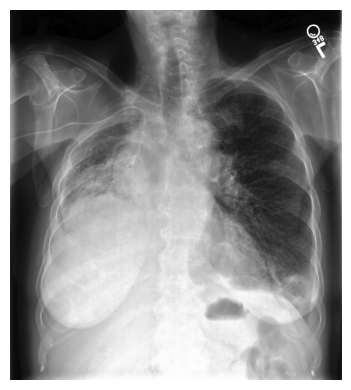


 PREDICTION:
The chest X-ray shows a normal cardiac silhouette with no evidence of cardiomegaly. There is no evidence of pleural effusion. The lung fields appear clear without any opacities or infiltrates. The trachea is centrally located. No pacemakers or tubes are visible. The ribs and spine are intact.

 GROUND TRUTH:
There is notable interval improvement in the right pleural effusion. There is a dense opacification with a rounded contour below the aerated right residual lung. Though the contour has the appearance of an elevated right hemidiaphragm, this appears to represent a large subpulmonic effusion when compared to ___ chest CT. There is improved aeration of the right lung with residual opacifications likely representing combination of atelectasis and known malignancy; cannot exclude superimposed infectious process. Atelectatic changes are noted within the left lower lung with a slightly greater degree of collapse in the posterior medial subsegment. Small left pleural effusion

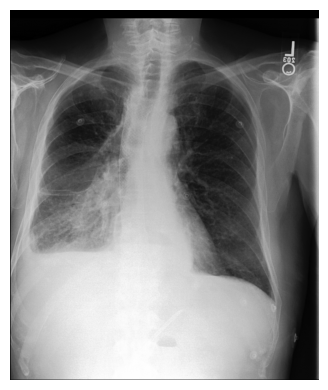


 PREDICTION:
The chest X-ray shows a normal cardiac silhouette with no evidence of cardiomegaly. There is no evidence of pleural effusion. The lung fields appear clear without any opacities or infiltrates. The trachea is centrally located. No pacemakers or tubes are visible in the image.

 GROUND TRUTH:
There is continued opacification of the right base. It is not significantly worsened since the prior exam. This may be due to a combination of pleural effusion, atelectasis, and aspiration. In the proper clinical setting, pneumonia cannot be excluded. There is a stable moderate right pleural effusion. There is a small left pleural effusion. No new consolidation is identified. There is no pulmonary edema or pneumothorax. The cardiomediastinal silhouette is normal. An esophageal stent is unchanged in position. A drain is present overlying the mid abdomen.

────────────────────────────────────────────────────────────────────────────────
Image 3
────────────────────────────────────────────

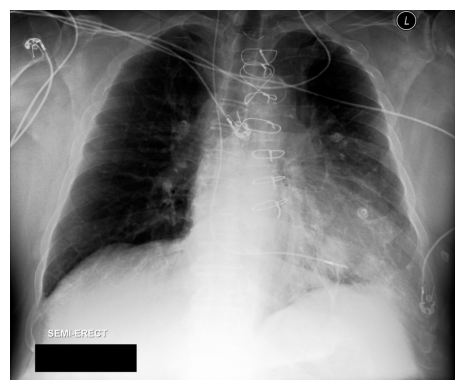


 PREDICTION:
The chest X-ray shows a normal cardiac silhouette with no evidence of cardiomegaly. There is no evidence of pleural effusion. The opacities in the right lung field appear to be due to the presence of a pacemaker lead and catheter. The left lung field appears clear. The overall appearance is consistent with a normal chest X-ray.

 GROUND TRUTH:
AP view of the chest. A temporary pacemaker lead is unchanged and in appropriate position. Mild cardiomegaly is unchanged. No focal consolidation, pleural effusion or pneumothorax.

────────────────────────────────────────────────────────────────────────────────
Image 4
────────────────────────────────────────────────────────────────────────────────


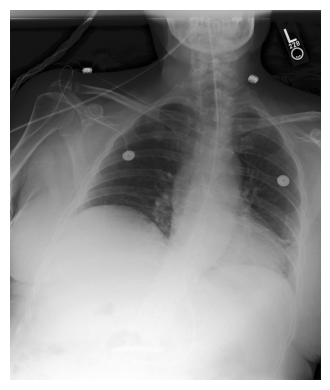


 PREDICTION:
The chest X-ray shows a normal cardiac silhouette with no evidence of cardiomegaly. There is no visible pleural effusion. The opacities in the right lung field appear to be due to the presence of a pacemaker lead and a tube, likely a central venous catheter. The overall lung fields appear clear without signs of consolidation or infiltrates.

 GROUND TRUTH:
A single portable chest radiograph was obtained. A Dobbhoff tube projects over the stomach. The tip is folded back on itself and points towards the body of the stomach. Lung volumes are low. Retrocardiac atelectasis has increased slightly. No effusion, consolidation, or pneumothorax is present.


In [61]:
import matplotlib.pyplot as plt

for i, (prediction, ground_truth) in enumerate(zip(out, ground_truths)):
    print(f"\n{'─'*80}")
    print(f"Image {i+1}")
    print(f"{'─'*80}")

    img = Image.open(image_paths.iloc[i])
    plt.figure(figsize=(8, 4))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    prediction = prediction.split('assistant')[-1].strip()
    print(f"\n PREDICTION:\n{prediction}")
    print(f"\n GROUND TRUTH:\n{ground_truth}")

## Reflection (5–8 sentences)

After running the model on your four images, briefly discuss:
- **What worked?**  
  Which prompts or parameter settings produced better results?
- **What failed?**  
  Were there recurring failure modes (e.g., hallucinations, vague answers)?
- **Patterns in mistakes**  
  Did errors correlate with certain categories, lighting conditions, or question phrasing?

**Initially, I had a longer max_token range, which did not do well. The model tended to repetitively drone about everything that was normal in the scan, and often ommitted some key abnormal findings. I also added the word "concise" to the prompt, which helped the model cut down on wasteful phrasing that gave us no information. In addition, I used a new system prompt, where I give the model the role of a radiologist.
The model in general seems quite weak, as in the examples above, only the second image does the model catch the chance of pneuomonia, in other images, the model either does not respond (i.e. image 4), or says everything is normal. This is probably because it is not trained to look for abnormalities yet. The errors I think correlate with the question phrasing. In general, I think the prompt is too vague in the term "findings". The model seems to recognize this term to mean "description" instead of "pathology list", which is actually what we want. This leads the model to use phrases such as "...shows a normal thoracic structure with..." many times in its response, instead of discussing pneumonia, pleural effusions, etc. Also, I think the prompt should distinctly include information about which things to look for, as this can guide the model's visual understanding. In image 3, we see the response uses the term "semi-erect" to discuss the position of the patient, and this is because the image is annotated with that term. We should not see this in a findings section, as this is just imaging metadata. We could prompt explicitly to avoid using these types of terms as well.**

# Problem 4: Prompt Engineering (15 points)

In this step, you'll experiment with **prompt design** to explore how different instructions influence model performance.

---

### Instructions

1. Modify the **`SYSTEM_PROMPT`** variable inside the **CHANGE ME** section of the code above.  
2. Re-run the corresponding code cell to observe how the model's responses change.  
3. Test various prompt strategies, such as:
   - Adding **examples** (few-shot prompting)
   - Restricting **answer formats** (e.g., "Answer with one word")
   - Asking for **explanations** or **step-by-step reasoning**
4. Compare your new results with the baseline output.

---

### Reflection

In your write-up, discuss:
- Which types of prompt changes improved performance?  
- Did adding context or structure help the model reason more effectively?  
- Were there any surprising or inconsistent results?


## **PROMPT ENGINEERING RESULTS**

Here are the prompts I use, as well as some basic rationale behind the choice of each prompt:

| Prompt | Rationale |
| --- | --- |
| "You are a radiologist." | Original |
| "You are a radiologist. Analyze chest X-rays systematically: cardiac silhouette, lungs, mediastinum, pleura." | Adding medical context. |
| "You are a radiologist. Think step-by-step: first describe findings, then identify abnormalities, then synthesize into a findings section." | Adding basic reasoning|
| "You are a radiologist. You will be writing down all findings for chest x-rays. <br> For example: Cardiomegaly with pulmonary edema, bilateral pleural effusions. <br>Identify pathology when present in clinical findings." | Few-shot (one example) learning|
| "You are an expert radiologist. Analyze chest X-rays and report all clinical findings. <br> Systematically evaluate: (1) Cardiac silhouette (2) Bilateral lungs (3) Existence of pleural effusion, cardiomegaly, pacemakers, tubes (4) Opacification. <br> Report normal findings and any abnormalities. Be concise and clinically accurate. Always give a response." | Combination |

**When we add medical context, we see a large improvement in the way that the model responds. For example, in image 1, we catch the right pleural effusion, which did not happen using the original prompt. However, we still get some repetitive phrasing for normal samples. In addition, the model still does not answer for image 4. Adding basic reasoning requirements significantly degrades performance. We observe missing responses for two of the images, and the other two are very long texts with little medical knowledge or proper findings. I think reasoning is the wrong improvement for this task, as we should be collecting visual artifacts (effusions, pacemakers, etc), not reasoning over a task (i.e. will the patient die in the next week, etc). With the few-shot example, where I give one example of a clinical findings section, there is again degradation of responses. Again, we do not answer two of the questions, and for the other two, we have no correct findings and repetitive phrasing. In order to synthesize the best response, I also tried a combination, where I expand upon the medical context prompt with more information, as well as better structure (adding explicit "always give an answer", as well as adding instructions for concise and medically accurate responses). This is by far the best method. We see that now, the model catches the existence of pacemakers and tubes. It is not perfect, as it still could not identify right and left effusions in images/2, but in general, this prompting strategy is much more capable.**



**The results are not very surprising, although I thought that adding an example would help. It seems that because the model is weak, adding an example leads to the model using that example's structure in all cases. Since findings are quite varied in response structure depending on the pathologies present, this lead to very repetitive and almost always medically inaccurate responses. The better method was giving specific things to look for, and then letting the model do the rest.**


# Problem 5: LoRA Fine-Tuning (20 points)

In this step, you'll fine-tune a **Vision-Language Model (VLM)** using **LoRA (Low-Rank Adaptation)** on your dataset.  
This exercise will help you understand how different hyperparameters influence performance, GPU memory usage, and output quality.

### Instructions

Run the code block below.  
If you followed the **`mmai-data`** example, the script should automatically detect and load your training dataset.

### Adjust and experiment with

- **Number of epochs** (`NUM_EPOCHS`)
- **Learning rate** (`LR`)
- **Batch size per device** (`BSZ_PER_DEV`)
- **Gradient accumulation steps** (`GRAD_ACCUM`)
- **Evaluation split ratio** (`EVAL_SPLIT`)
- **Random seed** (`SEED`)
- **Sequence length** (`MAX_SEQ_LEN`)
- **Image resolution** (`SHORTEST_EDGE`)
- **LoRA rank** (`LORA_R`)
- **LoRA alpha** (`LORA_ALPHA`)
- **LoRA dropout** (`LORA_DROPOUT`)
- **LoRA target modules** (`LORA_TARGET`)

---

```python
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

# (Modify the parameters below in the Colab cell)

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

### Q&A

**Q:** What should I do if I encounter an out-of-memory issue?  
**A:** Your image might be too large. Try resizing it by adding the following line back into your code and experiment with different pixel values:

```python
img.thumbnail((128, 128))  # NOTE: If you run into an out-of-memory error, try adding this line back.
```


In [110]:
# ==== Qwen2.5-VL-3B-Instruct • FP16 LoRA ====

from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model

# Environment hygiene
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 10
LR: float        = 5e-5
BSZ_PER_DEV: int = 2
GRAD_ACCUM: int  = 4
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 512  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
# Paths
DATA_JSONL: str  = "/content/drive/MyDrive/MIT/6.S985/data_train.jsonl"
OUTPUT_DIR: str  = "/content/drive/MyDrive/MIT/6.S985/qwen2_5_vl_lora_fp16_t4_attempt5"

MODEL_ID: str     = "Qwen/Qwen2.5-VL-3B-Instruct"
CACHE_DIR: str    = "/content/cache_images"
IMAGE_TIMEOUT: int = 15

# LoRA configuration (attention-only keeps memory low)
LORA_R: int          = 4
LORA_ALPHA: int      = 8
LORA_DROPOUT: float  = 0.1
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]

# Device / dtype policy
FORCE_CPU: bool   = False
DTYPE_IF_GPU      = torch.float16
DTYPE_IF_CPU      = torch.float32


# Repro and cache dirs
torch.manual_seed(SEED); random.seed(SEED)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --------------------
# Minimal JSONL dataset
# --------------------
class JsonlVisionLangDataset(Dataset):
    def __init__(self, jsonl_path: str):
        self.samples: list[dict] = []
        with open(jsonl_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line: continue
                ex = json.loads(line)
                if {"image","question","answer"} - set(ex.keys()): continue
                self.samples.append(ex)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx: int) -> Dict[str, Any]: return self.samples[idx]

full_ds = JsonlVisionLangDataset(DATA_JSONL)

# Manual split
n = len(full_ds); n_val = max(1, int(n * EVAL_SPLIT))
idx = list(range(n)); random.shuffle(idx)
val_idx = set(idx[:n_val])
train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data   = [full_ds[i] for i in range(n) if i in val_idx]

class ListDataset(Dataset):
    def __init__(self, data_list): self.data_list = data_list
    def __len__(self): return len(self.data_list)
    def __getitem__(self, i): return self.data_list[i]


# --------------------
# Cache images locally (avoid network hiccups)
# --------------------
BASE_DIR = os.path.dirname(DATA_JSONL)

def cache_image(url_or_path: str) -> str:
    # Remote URL: download and cache
    if url_or_path.startswith(("http://", "https://")):
        h = hashlib.md5(url_or_path.encode()).hexdigest()
        local = os.path.join(CACHE_DIR, f"{h}.jpg")
        if not os.path.exists(local):
            r = requests.get(url_or_path, timeout=IMAGE_TIMEOUT); r.raise_for_status()
            with open(local, "wb") as f: f.write(r.content)
        return local

    # Local path: make absolute relative to the JSONL file
    candidate = url_or_path
    # if not os.path.isabs(candidate):
    #     candidate = os.path.join(BASE_DIR, url_or_path)

    if not os.path.exists(candidate):
        raise FileNotFoundError(
            f"Image not found: {candidate} (from '{url_or_path}'). "
            f"Expected under {BASE_DIR}/"
        )
    return candidate


for ex in train_data: ex["image"] = cache_image(ex["image"])
for ex in val_data:   ex["image"] = cache_image(ex["image"])

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)


# --------------------
# Image loader
# --------------------
def load_image(img_path: str) -> Image.Image:
    img = Image.open(img_path).convert("RGB")
    # img.thumbnail((128, 128))  # NOTE: if you run into out of memory error, try adding this line back
    return img

# --------------------
# Processor + Model (FP16 on GPU, FP32 on CPU)
# --------------------
use_cuda = torch.cuda.is_available() and not FORCE_CPU
torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
device_map = "auto" if use_cuda else None

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 2),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


# --------------------
# Collator (truncate to keep sequences small)
# --------------------
@dataclass
class VLDataCollator:
    processor: Any
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images, texts = [], []
        for ex in features:
            img = load_image(ex["image"])
            messages = [
                {"role": "user", "content": [
                    {"type":"image","image": img},
                    {"type":"text","text": ex["question"]},
                ]},
                {"role": "assistant", "content": [
                    {"type":"text","text": ex["answer"]},
                ]},
            ]
            text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            images.append(img); texts.append(text)

        batch = self.processor(
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels

        for im in images:
            try: im.close()
            except: pass

        return batch

collator = VLDataCollator(processor)


# --------------------
# FP16 loss trainer to avoid fp32 upcast OOM
# --------------------
class FP16CLMTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,   # v5 may pass this
        **kwargs,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits  # keep fp16 path if available

        # Shift for causal LM
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=10,

    eval_strategy="steps",
    eval_steps=10,
    save_strategy="steps",
    save_steps=10_000,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 512, longest_edge to 2048


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491


Step,Training Loss,Validation Loss
10,4.455134,4.659878
20,4.579220,4.558684
30,4.364450,4.291976
40,4.068065,3.848529
50,3.602897,3.420321
60,3.230696,3.093468
70,2.948913,2.833258
80,2.792721,2.611654


KeyboardInterrupt: 

In [93]:
OUTPUT_DIR: str  = "/content/drive/MyDrive/MIT/6.S985/qwen2_5_vl_lora_fp16_t4_attempt6"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)

Training complete. LoRA adapters saved to: /content/drive/MyDrive/MIT/6.S985/qwen2_5_vl_lora_fp16_t4_attempt5


# **Questions to answer:**

1. Report the settings you used to get the best model.
| Hyperparameter | Value |
|--- | --- |
| NUM_EPOCHS  | 10|
| LR      | 5e-5 |
| BSZ_PER_DEV | 2 |
|GRAD_ACCUM | 4 |
|EVAL_SPLIT | 0.1 |
|SEED | 42 |
|MAX_SEQ_LEN | 512 |
|SHORTEST_EDGE | 512 |
|LORA_R | 4 |
|LORA_ALPHA | 8|
|LORA_DROPOUT| 0.1|
|LORA_TARGET| ["q_proj", "k_proj", "v_proj", "o_proj"]|
---
  
2. Which hyperparameters did you find have the most impact in the model’s performance?

**The first hyperparameter was the batch size, which I increased to 4, then decreased to 2, while increasing the graduate accumulation steps to 4. This was also helped by lowering the learning rate to 5e-5 from 1e-4. This allowed the model to actually make improvements. Another important hyperparameter was the image size. Because I was using medical imaging, fine details were important, so increasing the resolution helped.**

3. Why do you think that is?

**At small batches, I think the gradient step was too large, which caused a fluctuating loss that never converged downwards. Thus, when we increased the batch size and decreased the learning rate, we are smoothing the loss landscape and improving the optimizer's descent to a local optima. However, this convergence seemed to be a regression to the mean, where all responses were similar, so I decreased the batch size and increased the graduate accumulation steps in order to try to stop this. As mentioned above, increasing the resolution of the image helped a lot. There was little difference when trying out different LoRA configs, although I tried several combinations of R, alpha, and dropout.**



# Problem 6: Post-Training Evaluation (30 points)

# Problem 6.1 Load the Trained LoRA Adapter

Once your fine-tuning is complete, load the trained **LoRA adapters** back onto the original model to perform inference, that is, to generate predictions or analyze new images.

Simply run the code in the next code block.  
It will automatically attach your fine-tuned LoRA weights and prepare the model for evaluation.


In [111]:
OUTPUT_DIR: str  = "/content/drive/MyDrive/MIT/6.S985/qwen2_5_vl_lora_fp16_t4_attempt5"

# --------------------
# Inference with adapters
# --------------------
from peft import PeftModel
base = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="cuda:0",
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(base, OUTPUT_DIR)
ft_model.eval()
print("LoRA adapters loaded. Ready for inference.")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

LoRA adapters loaded. Ready for inference.


# Problem 6.2 Re-Test on Held-Out Images

Re-test the same **held-out images** used in your baseline evaluation.

Compare the **pre-trained** (in Step 2.2) and **fine-tuned** model outputs:

- Which questions showed improvement?  
- Did LoRA fine-tuning correct any earlier mistakes?  
- Were any new errors or biases introduced after fine-tuning?

Document your observations and include examples where possible.


In [122]:
import io
import os
import requests
import torch
from typing import Optional, Dict, Any
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from PIL import Image

# SYSTEM CONFIG
DO_SAMPLE: bool = False
TEMPERATURE: float = 0.5
TOP_P: float = 0.8
FORCE_CPU: bool = False
DTYPE_IF_GPU = torch.bfloat16
DTYPE_IF_CPU = torch.float32


######################################
###### Prompt Engineering Stuff ######
######################################
SYSTEM_PROMPT: str = """You are an expert radiologist. """
BASIC_PROMPT: str = """List clinical findings for this chest X-ray. """
MAX_NEW_TOKENS: int = 128
######################################
######################################

def get_device_and_dtype() -> tuple[torch.device, torch.dtype, Optional[Dict[str, Any]]]:
    use_cuda = torch.cuda.is_available() and not FORCE_CPU
    device = torch.device("cuda") if use_cuda else torch.device("cpu")
    torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
    device_map = "auto" if use_cuda else None
    return device, torch_dtype, device_map

device, torch_dtype, device_map = get_device_and_dtype()

def build_chat_messages(image: Image.Image, question: str) -> list[dict]:
    return [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_PROMPT}],
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        }
    ]

# Load 4 images
image_paths = test['image'].iloc[:4]
images = [Image.open(img_path) for img_path in image_paths]

# Build messages
messages = [build_chat_messages(img, BASIC_PROMPT) for img in images]

# Process
texts = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=texts, images=images, padding=True, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# Generate
gen_kwargs = dict(max_new_tokens=MAX_NEW_TOKENS, pad_token_id=processor.tokenizer.eos_token_id)
if DO_SAMPLE:
    gen_kwargs.update(dict(do_sample=True, temperature=TEMPERATURE, top_p=TOP_P, pad_token_id=processor.tokenizer.eos_token_id))

with torch.no_grad():
    gen_ids = ft_model.generate(**inputs, **gen_kwargs)

# Decode
out = processor.batch_decode(gen_ids, skip_special_tokens=True)
ground_truths = test['findings_section'].iloc[:4].tolist()




────────────────────────────────────────────────────────────────────────────────
Image 1
────────────────────────────────────────────────────────────────────────────────


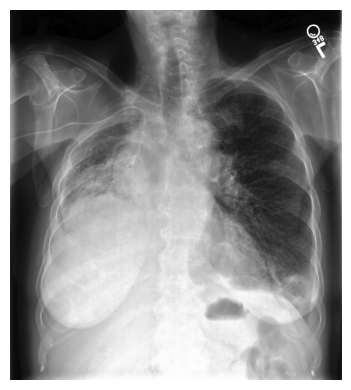


 PREDICTION:
The chest X-ray shows a normal heart size with no evidence of cardiomegaly. The lung fields are clear without signs of consolidation, pneumothorax, or pleural effusion. There is no evidence of a medical device such as a pacemaker or central venous catheter. The diaphragms are symmetric and move normally with respiration. No fractures are noted. The bony structures appear intact. The soft tissues are well-defined. The spine appears normal. The trachea is midline and not deviated. The diaphragm is at the level of the fourth rib. The cardiac silhouette is within normal limits

 GROUND TRUTH:
There is notable interval improvement in the right pleural effusion. There is a dense opacification with a rounded contour below the aerated right residual lung. Though the contour has the appearance of an elevated right hemidiaphragm, this appears to represent a large subpulmonic effusion when compared to ___ chest CT. There is improved aeration of the right lung with residual opacifica

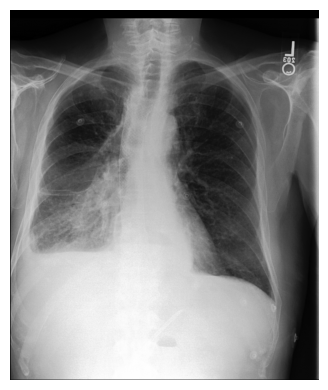


 PREDICTION:
The chest X-ray shows a normal heart size with no evidence of cardiomegaly. The lung fields are clear without signs of consolidation, pneumothorax, or pleural effusion. There is no evidence of foreign objects or medical devices within the thoracic cavity. The diaphragms appear to be in their usual positions without elevation or flattening. The bones and bony structures are unremarkable. No abnormal opacities are noted in the mediastinum. The trachea is centrally located. The soft tissues around the neck and chest are unremarkable. The diaphragm is in its usual position without

 GROUND TRUTH:
There is continued opacification of the right base. It is not significantly worsened since the prior exam. This may be due to a combination of pleural effusion, atelectasis, and aspiration. In the proper clinical setting, pneumonia cannot be excluded. There is a stable moderate right pleural effusion. There is a small left pleural effusion. No new consolidation is identified. There i

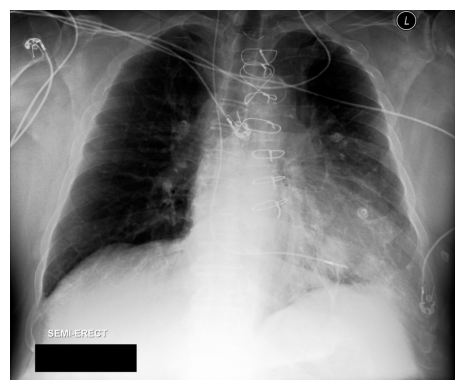


 PREDICTION:
The chest X-ray shows a normal heart size with no evidence of cardiomegaly. The lung fields are clear without signs of consolidation, pneumothorax, or pleural effusion. There is no evidence of a medical device such as a pacemaker or central venous catheter. The diaphragms are symmetric and move normally with respiration. No fractures are noted. The bony structures appear intact. The soft tissues are well-defined. The spine appears normal. The trachea is centered. The diaphragm is at the level of the fourth rib. The cardiac silhouette is not enlarged. The aortic arch is

 GROUND TRUTH:
AP view of the chest. A temporary pacemaker lead is unchanged and in appropriate position. Mild cardiomegaly is unchanged. No focal consolidation, pleural effusion or pneumothorax. 

────────────────────────────────────────────────────────────────────────────────
Image 4
────────────────────────────────────────────────────────────────────────────────


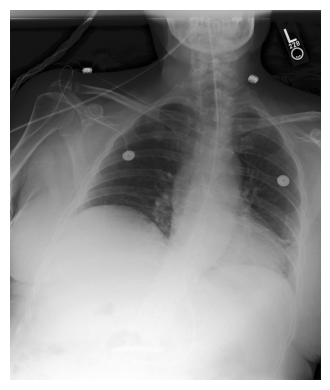


 PREDICTION:
The chest X-ray shows a normal heart size with no evidence of cardiomegaly. The lung fields are clear without signs of consolidation, pneumothorax, or pleural effusion. There is no evidence of a medical device such as a pacemaker or central venous catheter. The diaphragms are symmetric and move normally with respiration. No fractures are noted. The bony structures appear intact. The soft tissues are well-defined. The spine appears normal. The trachea is centered. The diaphragm is at the level of the fourth rib. The cardiac silhouette is not enlarged. The aortic arch is

 GROUND TRUTH:
A single portable chest radiograph was obtained. A Dobbhoff tube projects over the stomach. The tip is folded back on itself and points towards the body of the stomach. Lung volumes are low. Retrocardiac atelectasis has increased slightly. No effusion, consolidation, or pneumothorax is present. 


In [123]:
import matplotlib.pyplot as plt

for i, (prediction, ground_truth) in enumerate(zip(out, ground_truths)):
    print(f"\n{'─'*80}")
    print(f"Image {i+1}")
    print(f"{'─'*80}")

    img = Image.open(image_paths.iloc[i])
    plt.figure(figsize=(8, 4))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    prediction = prediction.split('assistant')[-1].strip()
    print(f"\n PREDICTION:\n{prediction}")
    print(f"\n GROUND TRUTH:\n{ground_truth} ")

## **Discussion of Results from LoRA**:

**It seems that in general, LoRA fine-tuning actually hurt generation. While originally, we had at least varied responses, fine-tuning lead to a regression to the means. I think this is because of the high variety of responses in the dataset, coupled with the many negative examples in the dataset, where there were no clinical findings. These two factors together lead to the model converging to just reporting that every image had no medically relevant abnormalities, even though we know this is the case. For example, in image 3, originally we found the pacemaker (after explicitly prompting to check, though). Now, we just give the same answer that we did for images 1,2 and 4. In addition, we see some run-on behavior, where the model continues its responses past coherence, essentially just rambling. Sadly, there are no cases from this held-out set where the fine-tuning fixed errors, and more where we introduced errors.**

# Problem 7: Final Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. What concept did you find the most interesting?

**I think the most interesting concepts were in the reading on multimodal few-shot learning, because it is such a fundamental idea behind multimodal learning. I think now, the idea seems outdated, since there are much more sophisticated ways to train multimodal LLMs, but still, the idea of mapping images to an embedding space that LLMs can process is very foundational.**

2. Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.

**I think fine-tuning in general is a very useful skill, since more often than not, we use datasets of a specific type (medical, etc), and so to post-train the model to best suit your dataset can be beneficial to downstream tasks. Personally, I have only ever done fine-tuning by unfreezing the last layer(s) of the LLM and doing supervised learning with a classification head, but the LoRA methodology is another good tool for more free-text based datasets.**

3. Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more?

**N/A**.